# Обучение дерева на сортах вина — `wine_train.ipynb`

Это ноутбук **обучающего этапа** недельного проекта. Здесь мы загружаем датасет, проводим EDA, обучаем `DecisionTreeClassifier`, подбираем регуляризацию и сохраняем готовую модель в `wine_model.pkl`. На этапе сервиса (Шаг 2 проекта и далее) этот pickle загружается в FastAPI и отдаётся через браузерную форму.

## Бизнес-сценарий

Винодельня в одном итальянском регионе делает вино из трёх сортов винограда: `class_0`, `class_1` и `class_2`. Перед розливом в каждой партии лаборатория измеряет 13 ключевых химических показателей: содержание алкоголя, фенолов, флавоноидов, цветовую интенсивность.

**Реалистичная сложность.** Лаборант, который размечает партии в логах, иногда ошибается. Не часто, но и не редко — около 10-15% случаев. Это значит, что **обучающая выборка содержит шум в разметке** (label noise). Тестовую выборку мы получили от независимого аудитора, и она чистая. Главный вопрос недели: можно ли по шумной разметке обучить надёжную модель? Регуляризация — основной инструмент, который защищает дерево от подгонки под ошибочные точки в train.

## Как читать этот ноутбук

Ноутбук **пошаговый**. Каждый этап разбит на маленькие ячейки: одна делает что-то одно (загружает данные, рисует график, считает метрику). После каждого блока есть markdown-комментарий, что мы только что увидели и что собираемся сделать дальше. Идите сверху вниз и не пропускайте markdown — без него код выглядит как набор магических заклинаний.

## Этапы

1. **EDA** — что в данных: распределения, баланс классов, корреляции
2. **Split + label noise** — делим train/test, в train кладём шум разметки 15%
3. **Базовая модель** — обучим дерево без регуляризации и увидим переобучение
4. **Регуляризация** — подберём `max_depth` и `min_samples_leaf` через кросс-валидацию
5. **Сравнение** — графически сравним baseline и финальную модель
6. **Сохранение** — сериализуем готовую модель в `wine_model.pkl`

## Окружение

Запускаем в стандартном окружении курса (`conda activate task-api`). Используем `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `joblib`.

In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


Зафиксируем зерно случайности. `random_state=42` — общепринятый seed: важна не сама цифра, а то, что одна и та же цифра у всех даёт одинаковый split. Без фиксации каждый запуск ноутбука даст немного разные числа.

In [3]:
SEED = 42
np.random.seed(SEED)


Куда сохраним обученную модель. Путь относительный — файл ляжет рядом с ноутбуком, в той же папке, откуда вы его запускаете. На Шаге 7 проекта вы скопируете этот `wine_model.pkl` в `task-api/models/`.

In [4]:
MODEL_PATH = Path("wine_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## Этап 1. EDA — что в данных

Прежде чем обучать модель, нужно понять, с чем работаем.

### 1.1 Загружаем датасет

**Wine** — встроенный sklearn-датасет (`sklearn.datasets.load_wine`). 178 партий вина из одного итальянского региона, 13 числовых признаков химического анализа, 3 класса культивара.

In [5]:
# твой код
data = load_wine(as_frame=True)
X = data.data
y = data.target

In [6]:
# твой код
print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (178, 13)
Размер y: (178,)


Получили 178 строк × 13 признаков и вектор таргета той же длины.

In [7]:
# твой код
list(X.columns)

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

Имена признаков химические. Самые узнаваемые — `alcohol`, `flavanoids`, `proline`, `color_intensity`, `hue`.

In [8]:
# твой код
list(data.target_names)

[np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Три класса. В оригинальном датасете названия закрыты — это три разных культивара (сорта винограда) одного производителя.

Заглянем в первые строки:

In [9]:
# твой код
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Все признаки числовые, разного масштаба. `proline` в сотнях, `hue` в десятых, `alcohol` около 13. Для линейных моделей пришлось бы стандартизировать через `StandardScaler`. Для **дерева** — не нужно: оно строит сплиты по порогам (`feature > 1.5`), а порог инвариантен к монотонным преобразованиям масштаба.

### 1.2 Баланс классов

Если один класс сильно доминирует, accuracy будет завышенной (модель угадывает большинство и формально «работает», хотя реально не учится). Проверим распределение.

In [10]:
# твой код
class_counts = pd.Series(y).map(dict(enumerate(data.target_names))).value_counts()
class_counts

target
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Посчитаем долю каждого класса:

In [11]:
# твой код
class_proportions = (class_counts / class_counts.sum() * 100).round(1)
class_proportions

target
class_1    39.9
class_0    33.1
class_2    27.0
Name: count, dtype: float64

Распределение **примерно сбалансированное**: ни один класс не меньше 25%. `class_weight="balanced"` нам не понадобится. На графике это виднее:

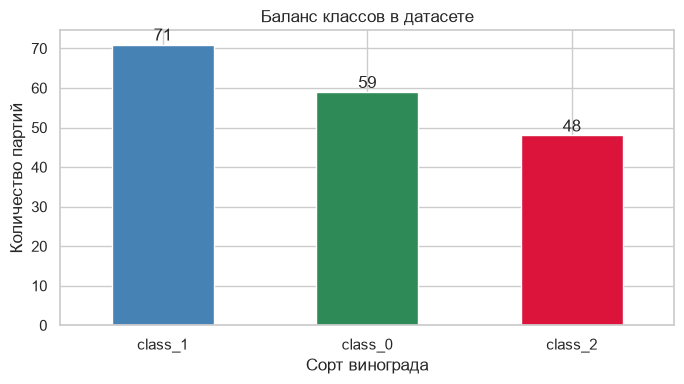

In [12]:
# твой код
fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind="bar", ax=ax, color=["steelblue", "seagreen", "crimson"])
ax.set_title("Баланс классов в датасете")
ax.set_xlabel("Сорт винограда")
ax.set_ylabel("Количество партий")
ax.set_xticklabels(class_counts.index, rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

Класс `class_1` чуть впереди (40%), но разрыв с остальными умеренный. На multiclass с таким балансом общая accuracy остаётся честной метрикой.

### 1.3 Как выглядит один признак

Прежде чем смотреть все 13 признаков сразу, посмотрим на один — `alcohol`. Это самый интуитивный показатель.

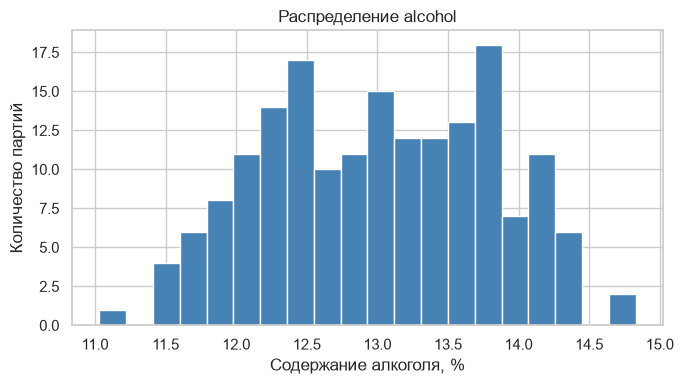

In [13]:
# твой код
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(X["alcohol"], bins=20, color="steelblue", edgecolor="white")
ax.set_title("Распределение alcohol")
ax.set_xlabel("Содержание алкоголя, %")
ax.set_ylabel("Количество партий")
plt.tight_layout()
plt.show()

Распределение **бимодальное**: видны два «горба». Это хорошо для классификации — два горба намекают, что разные классы группируются вокруг разных значений признака. Чтобы убедиться, посмотрим на распределение алкоголя **по классам**:

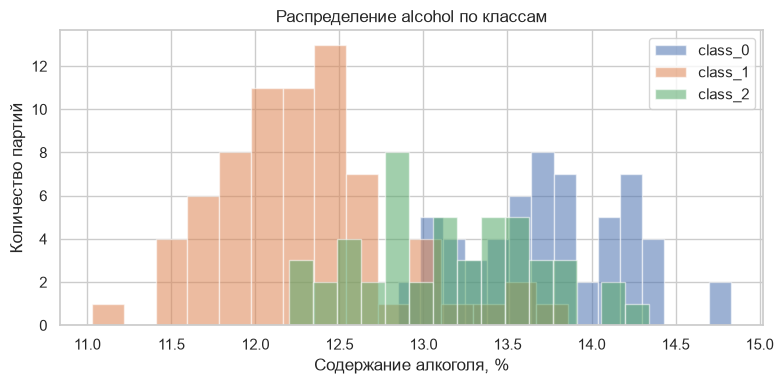

In [14]:
# твой код
fig, ax = plt.subplots(figsize=(8, 4))
for cls_idx, cls_name in enumerate(data.target_names):
    ax.hist(
        X["alcohol"][y == cls_idx],
        bins=15,
        alpha=0.55,
        label=cls_name,
    )
ax.set_title("Распределение alcohol по классам")
ax.set_xlabel("Содержание алкоголя, %")
ax.set_ylabel("Количество партий")
ax.legend()
plt.tight_layout()
plt.show()

Видно: `class_0` концентрируется на 13.5+, `class_1` около 12, `class_2` где-то посередине. Алкоголь — дискриминативный признак, дерево сможет построить по нему полезный сплит.

### 1.4 Все 13 признаков в сетке

Теперь посмотрим на все 13 признаков одним взглядом — каждый в своей маленькой ячейке. Сетка 4×4: 13 признаков займут 13 ячеек, 3 останутся пустыми.

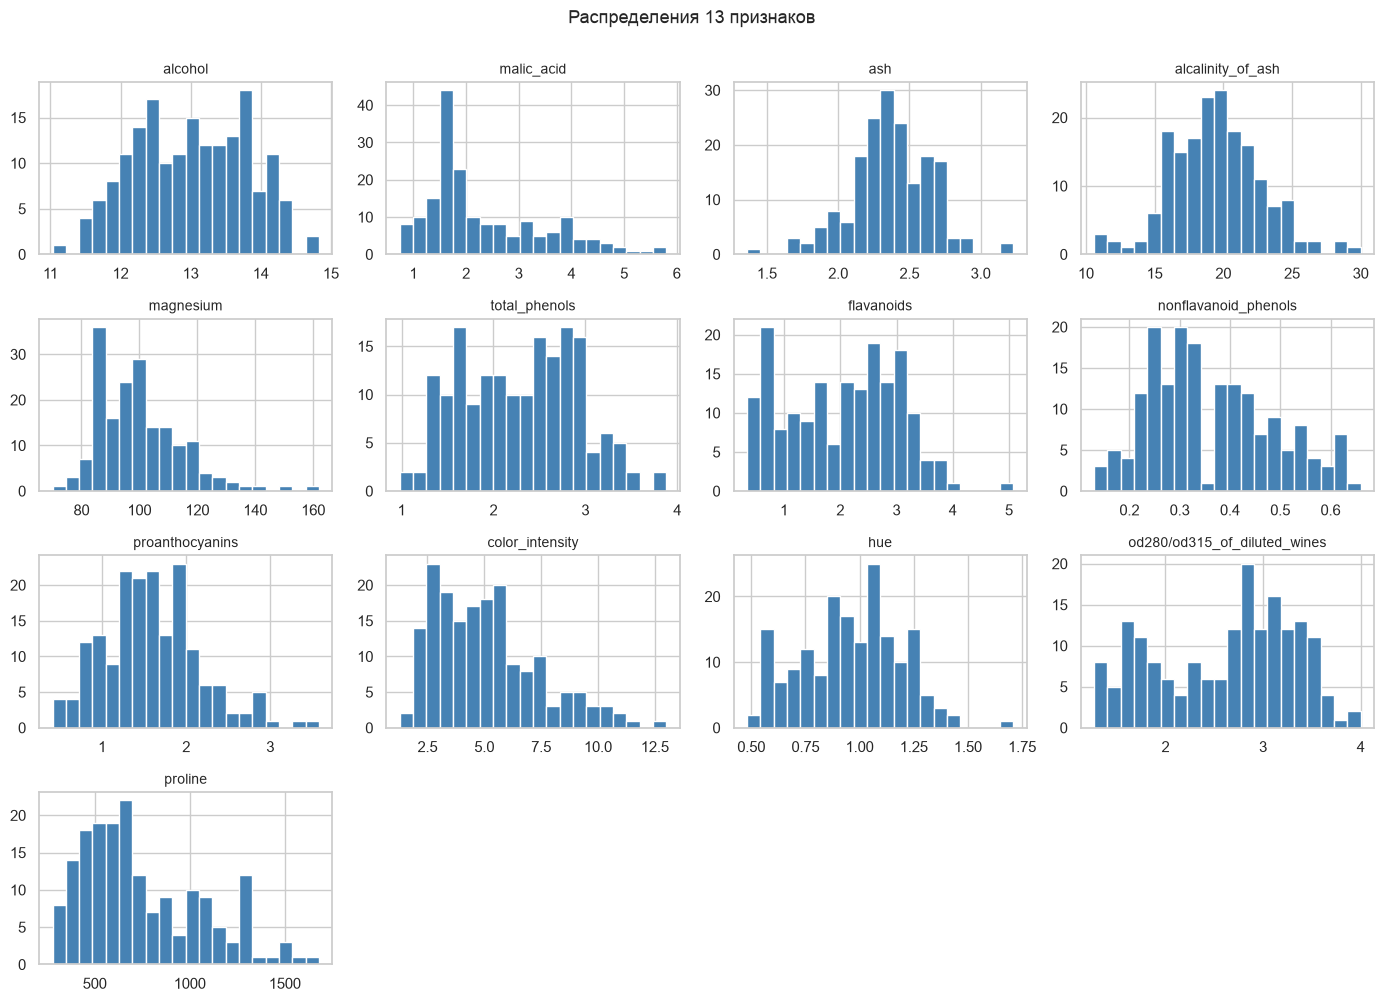

In [15]:
# твой код
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(X.columns):
    axes[i].hist(X[feat], bins=20, color="steelblue", edgecolor="white")
    axes[i].set_title(feat, fontsize=10)

for j in range(len(X.columns), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Распределения 13 признаков", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

Большинство распределений унимодальные (одна вершина), некоторые — `proline`, `magnesium` — со скосом вправо (длинный хвост в большие значения). Бимодальных, как у `alcohol`, чётко видных тут больше нет — классы будут различаться комбинациями признаков, а не одним резким разделителем.

### 1.5 Где классы реально различаются

Гистограмма всего датасета не отвечает на главный вопрос: **различаются ли классы по этому признаку**. Для этого есть boxplot по классам. Если коробки трёх классов расположены по-разному (по медиане), значит признак содержит сигнал. Если перекрываются — признак бесполезен.

Возьмём `flavanoids` — один из самых известных предикторов в Wine.

In [16]:
# твой код
df_box = X[["flavanoids"]].copy()
df_box["target"] = pd.Categorical.from_codes(y, categories=data.target_names)
df_box.head(3)

,flavanoids,target
0,3.06,class_0
1,2.76,class_0
2,3.24,class_0


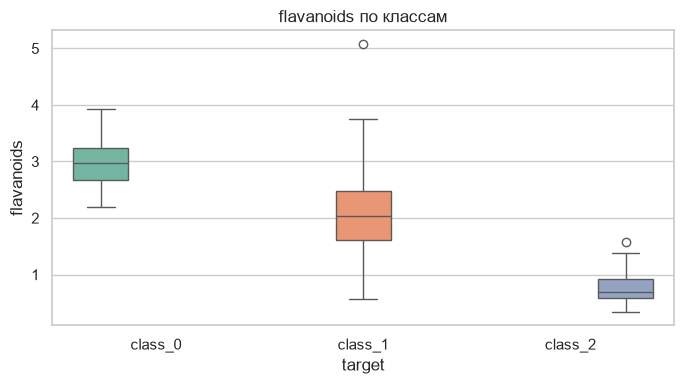

In [17]:
# твой код
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_box, x="target", y="flavanoids", ax=ax, palette="Set2", hue="target", legend=False)
ax.set_title("flavanoids по классам")
plt.tight_layout()
plt.show()

Три коробки расположены **последовательно по медиане**: у `class_0` высокий уровень флавоноидов, у `class_1` средний, у `class_2` низкий. Перекрытий минимум. Это сильнейший разделитель — дерево скорее всего выберет именно этот признак для верхнего сплита.

### 1.6 Boxplot для топ-6 признаков

Соберём ту же картинку для шести самых важных признаков. По разделимости коробок будем понимать, кто из них вносит сигнал.

In [18]:
# твой код
top_features = [
    "alcohol",
    "flavanoids",
    "color_intensity",
    "proline",
    "od280/od315_of_diluted_wines",
    "hue",
]

df_for_box = X[top_features].copy()
df_for_box["target"] = pd.Categorical.from_codes(y, categories=data.target_names)

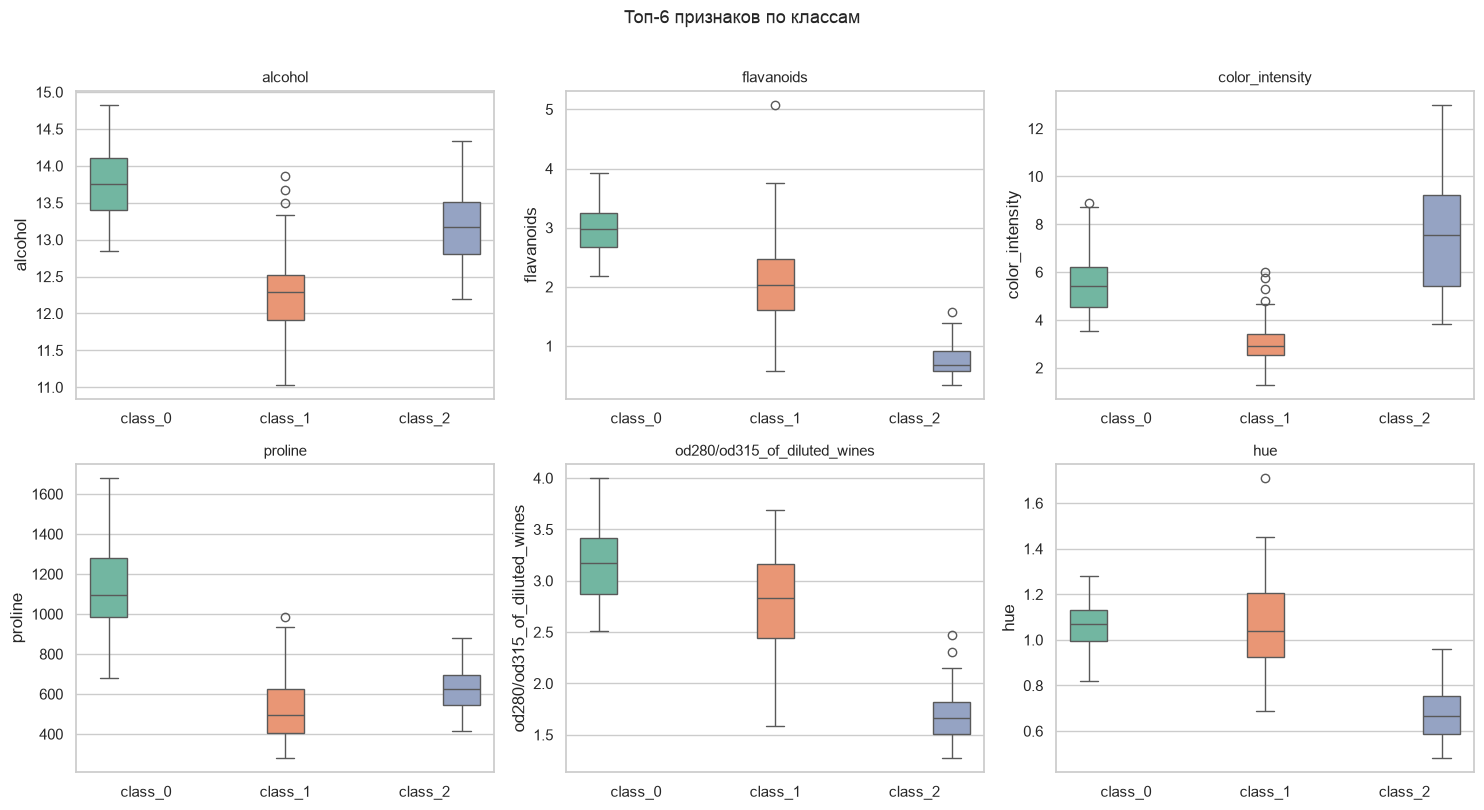

In [19]:
# твой код
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(
        data=df_for_box, x="target", y=feat, ax=axes[i],
        palette="Set2", hue="target", legend=False,
    )
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")

fig.suptitle("Топ-6 признаков по классам", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Что видим:**

- `flavanoids` и `od280/od315_of_diluted_wines` — почти идеальное разделение
- `proline` чётко выделяет `class_0` (высокий) от двух других
- `alcohol` отделяет `class_0` (выше) и `class_1` (ниже), но `class_2` пересекается с обоими
- `color_intensity` и `hue` менее дискриминативны, но всё ещё несут сигнал

Этих признаков достаточно для построения хорошего дерева.

### 1.7 Корреляции между признаками

Корреляционная матрица показывает, какие признаки несут одинаковую информацию. Высокая корреляция (> 0.8 по модулю) — значит одно из двух можно убрать. Для дерева это не критично (оно само выберет), но полезно понимать структуру.

In [20]:
# твой код
corr = X.corr().round(2)
corr.iloc[:5, :5]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
alcohol,1.00,0.09,0.21,-0.31,0.27
malic_acid,0.09,1.00,0.16,0.29,-0.05
ash,0.21,0.16,1.00,0.44,0.29
alcalinity_of_ash,-0.31,0.29,0.44,1.00,-0.08
magnesium,0.27,-0.05,0.29,-0.08,1.00


Это первые 5×5 значений. Чтобы увидеть всю матрицу — heatmap:

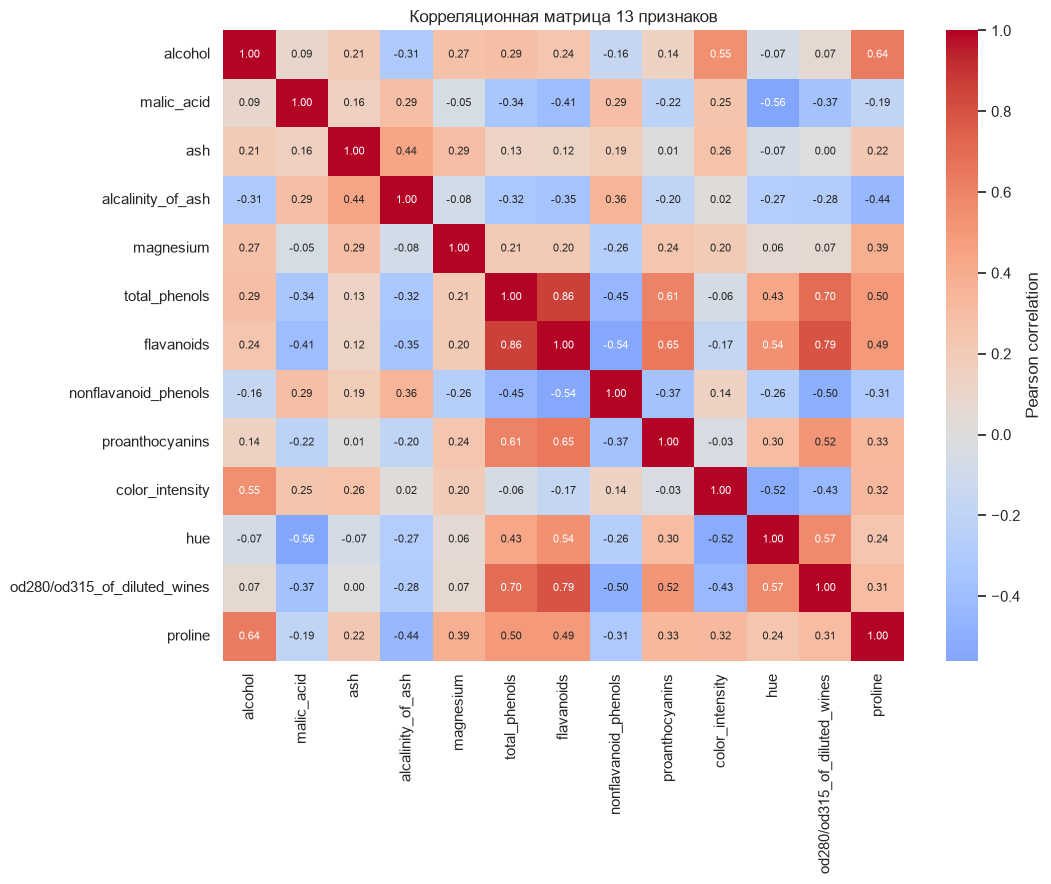

In [21]:
# твой код
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    cbar_kws={"label": "Pearson correlation"}, ax=ax, annot_kws={"size": 8},
)
ax.set_title("Корреляционная матрица 13 признаков")
plt.tight_layout()
plt.show()

**Главная пара с высокой корреляцией:** `flavanoids` ↔ `total_phenols` (≈ 0.86), `flavanoids` ↔ `od280/od315_of_diluted_wines` (≈ 0.79). Это химически осмысленно — флавоноиды это подкласс фенолов. Дерево возьмёт одну из коррелирующих фичей в сплит, остальное проигнорирует. Никаких действий с нашей стороны не нужно.

## Этап 2. Делим train/test и добавляем шум в разметку

Сначала чистый split 60/40 со `stratify=y`. Test трогаем **только в самом конце** — на нём измерим финальную метрику.

Потом в **обучающую** часть кладём label noise: переразметим 15% случайных строк на неправильный класс. Это симулирует реальную ситуацию — лаборант ошибается. Тестовую часть оставляем чистой (это аудит).

### 2.1 Чистый train/test split

In [22]:
# TODO: раздели X, y на train (60%) и test (40%).
# Используй train_test_split со stratify=y и random_state=SEED.
# Подсказка: X_train, X_test, y_train_clean, y_test = train_test_split(...)
# Решение: смотри wine_train_solution.ipynb если застрял

X_train, X_test, y_train_clean, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=SEED,
)


In [23]:
# твой код
print("Train:", X_train.shape[0], "строк")
print("Test:", X_test.shape[0], "строк")

Train: 106 строк
Test: 72 строк


### 2.2 Добавляем label noise в train

15% строк train получат **неправильный** класс. Это симулирует ошибки лаборанта при разметке. Тест остаётся как есть.

In [24]:
# твой код
rng = np.random.default_rng(SEED)
NOISE_RATE = 0.15
n_flip = int(NOISE_RATE * len(y_train_clean))
n_flip

15

Это число строк, которым переставим метку. Для каждой выбранной строки сдвигаем её класс на 1 или 2 (по модулю 3) — то есть присваиваем какой-то другой класс из трёх возможных:

In [25]:
# твой код
flip_idx = rng.choice(len(y_train_clean), size=n_flip, replace=False)
shifts = rng.integers(1, 3, size=n_flip)  # 1 или 2

y_train_noisy = y_train_clean.copy()
y_train_noisy.iloc[flip_idx] = (y_train_clean.iloc[flip_idx].values + shifts) % 3

Сравним сколько меток отличается:

In [26]:
# твой код
changed = (y_train_noisy != y_train_clean).sum()
total = len(y_train_clean)
print(f"Изменено меток: {changed} из {total} ({changed/total*100:.1f}%)")

Изменено меток: 15 из 106 (14.2%)


Дальше используем `y_train_noisy` — это то, с чем работает модель. `y_train_clean` нам нужен только для отладки и сравнения. Test остаётся `y_test` — чистый аудит.

In [27]:
# твой код
y_train = y_train_noisy  # дальше работаем с шумной разметкой

## Этап 3. Базовая модель — учимся видеть переобучение

Сначала обучим дерево **без ограничений** (`max_depth=None`, `min_samples_leaf=1`) и посмотрим, что получится. Это полезный baseline по двум причинам:

1. Видим переобучение в чистом виде — train accuracy уйдёт в 1.0, test останется ниже
2. Получаем точку отсчёта для сравнения — все улучшения от регуляризации измеряются относительно этой модели

### 3.1 Обучаем дерево без регуляризации

In [28]:
# TODO: создай DecisionTreeClassifier без регуляризации (только random_state=SEED)
# и обучи на X_train, y_train (это уже шумная разметка).
clf_baseline = DecisionTreeClassifier(random_state=SEED)
clf_baseline.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

Дерево обучилось мгновенно (на сотне строк это секунды). Смотрим accuracy на train:

In [29]:
# TODO: посчитай accuracy на train. Используй accuracy_score(y_true, y_pred)
# и .predict() метод модели.

train_acc_base = accuracy_score(y_train, clf_baseline.predict(X_train))
train_acc_base


1.0

**Accuracy на train = 1.0** — модель идеально запомнила обучающую выборку, **включая её ошибки разметки**. Дерево без ограничений всегда может выучить train на 100%: оно просто наращивает сплиты, пока каждая точка не оказывается в собственном листе. Вместе с реальными зависимостями модель выучила и шум разметки — это и есть переобучение.

Теперь test (он чистый, без label noise):

In [30]:
# TODO: то же самое для test.

test_acc_base = accuracy_score(y_test, clf_baseline.predict(X_test))
test_acc_base


0.7638888888888888

In [31]:
# твой код
f"Gap (train - test): {train_acc_base - test_acc_base:.4f}"

'Gap (train - test): 0.2361'

**Gap большой**. Между train (1.0) и test (~0.76) разрыв в 24% — это и есть переобучение в чистом виде. Дерево разрослось до состояния «по одному листу почти на каждое наблюдение train» и теряется на новых данных. На test, где разметка чистая, модель ошибается чаще — потому что она училась с погрешностями в train.

### 3.2 Насколько разрослось дерево

In [32]:
# твой код
clf_baseline.tree_.max_depth

8

In [33]:
# твой код
clf_baseline.get_n_leaves()

np.int64(22)

In [34]:
# твой код
clf_baseline.tree_.node_count

43

Дерево глубиной 6-9 уровней с 12-18 листьями — слишком сложное для сотни строк train. Каждый лист в среднем покрывает 5-9 наблюдений. Лекарство — **регуляризация**: ограничим, как глубоко может расти дерево и сколько примеров обязано быть в листе.

## Этап 4. Подбор регуляризации

У `DecisionTreeClassifier` есть два главных гиперпараметра, которые контролируют сложность дерева:

- **`max_depth`** — максимальная глубина дерева. Чем меньше, тем проще модель и тем хуже она запоминает шум
- **`min_samples_leaf`** — минимальное число наблюдений в листе. Чем больше, тем стабильнее модель: один выброс не создаст лист на самого себя

Подбор делаем в два захода: сначала валидационная кривая по `max_depth`, потом `GridSearchCV` по обоим параметрам сразу. Test трогать на этом этапе **запрещено** — он только для финальной независимой проверки.

### 4.1 Валидационная кривая по `max_depth`

Идея: для каждой глубины посчитать train accuracy (на трейне) и cross-val accuracy (среднее по 5 фолдам внутри трейна). Когда train сильно выше CV — переобучение. Когда они близки и CV максимальный — оптимум.

Сначала перебираем глубины и для каждой обучаем дерево на полном train, потом запускаем 5-fold CV. Делаем это в цикле.

In [35]:
# твой код
depths = [2, 3, 4, 5, 6, 8, 10, None]
depths

[2, 3, 4, 5, 6, 8, 10, None]

Цикл по глубинам — для каждой считаем train accuracy и CV accuracy:

In [36]:
# TODO: для каждого max_depth из списка depths выше:
#   1) обучи DecisionTreeClassifier(max_depth=depth, random_state=SEED) на (X_train, y_train)
#   2) запиши accuracy на train в список train_scores
#   3) посчитай cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
#      и запиши .mean() в cv_scores, .std() в cv_stds

train_scores = []
cv_scores = []
cv_stds = []


for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))

    cv = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_scores.append(cv.mean())
    cv_stds.append(cv.std())

ERROR:root:code for hash blake2b was not found.
Traceback (most recent call last):
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 129, in __get_openssl_constructor
    return __get_builtin_constructor(name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 123, in __get_builtin_constructor
    raise ValueError('unsupported hash type ' + name)
ValueError: unsupported hash type blake2b
ERROR:root:code for hash blake2s was not found.
Traceback (most recent call last):
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Misha/.pyenv/ve

Получили три параллельных списка. Соберём их в DataFrame:

In [37]:
# твой код
results_curve = pd.DataFrame({
    "max_depth": [str(d) if d is not None else "None" for d in depths],
    "train_acc": np.round(train_scores, 4),
    "cv_acc": np.round(cv_scores, 4),
    "cv_std": np.round(cv_stds, 4),
})
results_curve

,max_depth,train_acc,cv_acc,cv_std
0,2,0.8585,0.7636,0.0962
1,3,0.9057,0.7827,0.0837
2,4,0.9340,0.7831,0.0930
3,5,0.9528,0.7736,0.0922
4,6,0.9623,0.7736,0.0922
5,8,1.0000,0.7645,0.0657
6,10,1.0000,0.7645,0.0657
7,None,1.0000,0.7645,0.0657


**Что видно из таблицы:**

- При маленькой глубине (`max_depth=2`) train невысокий — дерево слишком простое
- При большой (`max_depth=10` или `None`) train близок к 1.0, CV выходит на плато
- CV максимальный где-то посередине — это и есть оптимум

Нагляднее на графике.

### 4.2 Рисуем валидационную кривую

In [38]:
# твой код
x_axis = [d if d is not None else 12 for d in depths]
x_labels = [str(d) if d is not None else "None" for d in depths]

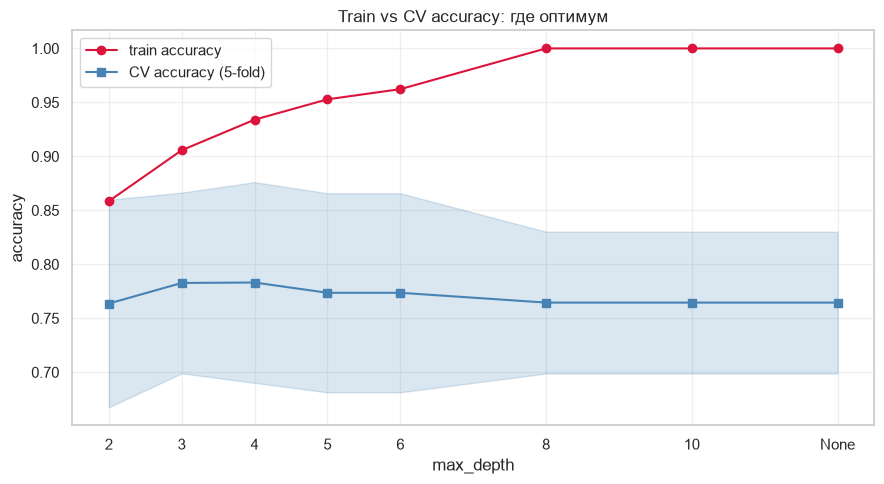

In [39]:
# твой код
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_axis, train_scores, marker="o", label="train accuracy", color="crimson")
ax.plot(x_axis, cv_scores, marker="s", label="CV accuracy (5-fold)", color="steelblue")
ax.fill_between(
    x_axis,
    np.array(cv_scores) - np.array(cv_stds),
    np.array(cv_scores) + np.array(cv_stds),
    alpha=0.2,
    color="steelblue",
)
ax.set_xticks(x_axis)
ax.set_xticklabels(x_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Train vs CV accuracy: где оптимум")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Чтение графика:**

- Красная (train) растёт до 1.0 при глубине 5+ — модель запоминает train со всеми его погрешностями
- Синяя (CV) выходит на плато около depth 3-4 и дальше **не растёт**
- Между линиями растёт **gap** — это переобучение
- Заштрихованная синяя зона (± std) показывает, насколько стабильна CV-метрика

Оптимум — там, где CV максимальный и gap ещё небольшой.

### 4.3 GridSearchCV: тюним два параметра сразу

Валидационная кривая — для одного параметра. Если хотим тюнить `max_depth` и `min_samples_leaf` одновременно, нужен grid search: перебрать все комбинации и выбрать лучшую по CV-accuracy.

Сетку берём небольшую — 4 × 5 = 20 комбинаций × 5 фолдов = 100 fit'ов. Это пара секунд.

In [40]:
# TODO: задай param_grid для GridSearchCV.
# Параметры для перебора: max_depth (попробуй 2-5) и min_samples_leaf (попробуй 1-10).

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 4, 6, 10],
}
param_grid


{'max_depth': [2, 3, 4, 5], 'min_samples_leaf': [1, 2, 4, 6, 10]}

In [44]:
# TODO: создай GridSearchCV с estimator=DecisionTreeClassifier(random_state=SEED),
# param_grid (как выше), cv=5, scoring="accuracy", n_jobs=-1.
# Запусти grid.fit(X_train, y_train).

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 4, 6, 10],
}
param_grid


{'max_depth': [2, 3, 4, 5], 'min_samples_leaf': [1, 2, 4, 6, 10]}

GridSearchCV сам перебрал комбинации и выбрал лучшую:

In [47]:
# твой код
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

ERROR:root:code for hash blake2b was not found.
Traceback (most recent call last):
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 129, in __get_openssl_constructor
    return __get_builtin_constructor(name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 123, in __get_builtin_constructor
    raise ValueError('unsupported hash type ' + name)
ValueError: unsupported hash type blake2b
ERROR:root:code for hash blake2s was not found.
Traceback (most recent call last):
  File "/Users/Misha/.pyenv/versions/3.12.3/lib/python3.12/hashlib.py", line 245, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/Misha/.pyenv/ve

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 4, 6, 10]},
             scoring='accuracy')

In [48]:
# твой код
grid.best_params_


{'max_depth': 4, 'min_samples_leaf': 1}

Посмотрим топ-5 комбинаций — какие ещё параметры были близки к лидеру:

In [49]:
# твой код
f"Best CV accuracy: {grid.best_score_:.4f}"

'Best CV accuracy: 0.7831'

In [50]:
top_results = pd.DataFrame(grid.cv_results_)[
    ["param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False).head()
top_results.round(4)

,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score
10,4,1,0.7831,0.0930
5,3,1,0.7827,0.0837
15,5,1,0.7736,0.0922
3,2,6,0.7732,0.1109
7,3,4,0.7641,0.0953


Лучшая комбинация — небольшое дерево с увеличенным `min_samples_leaf`. Этот же набор параметров используем дальше в финальной модели.

## Этап 5. Финальная модель + честная оценка на test

Обучаем дерево с лучшими гиперпараметрами на полном train (со всем шумом разметки!), затем измеряем accuracy на test (test трогаем здесь **впервые**).

In [53]:
# TODO: создай финальную модель с лучшими параметрами grid.best_params_
# (распакуй через **) и random_state=SEED. Обучи на X_train, y_train.

clf_final = DecisionTreeClassifier(**grid.best_params_, random_state=SEED)
clf_final.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [54]:
# TODO: train accuracy финальной модели.
train_acc_final = accuracy_score(y_train, clf_final.predict(X_train))
train_acc_final


0.9339622641509434

Train accuracy у финальной модели **ниже 1.0** — это сознательный отказ от запоминания каждой точки. Те 15% строк с шумной разметкой модель всё равно отнесёт к их «настоящему» классу, не пытаясь подгоняться.

In [55]:
# TODO: test accuracy финальной модели.

test_acc_final = accuracy_score(y_test, clf_final.predict(X_test))
test_acc_final


0.8333333333333334

In [56]:
# твой код
f"Final gap (train - test): {train_acc_final - test_acc_final:.4f}"

'Final gap (train - test): 0.1006'

**Сравним с baseline:**

| Метрика | Baseline | Final |
|---|---|---|
| train accuracy | 1.0 | ниже 1.0 (модель не запоминает каждую точку) |
| test accuracy | ~0.76 | выше baseline (регуляризация защитила от шума разметки) |
| gap | ~0.24 | сильно меньше |

Регуляризация дала видимый эффект: test поднялся, gap сузился. На multiclass с label noise это и есть главное доказательство, что регуляризация работает.

### 5.1 Подробные метрики на test

In [57]:
# твой код
y_pred_final = clf_final.predict(X_test)
print(classification_report(y_test, y_pred_final, target_names=data.target_names))

              precision    recall  f1-score   support

     class_0       0.71      1.00      0.83        24
     class_1       0.95      0.69      0.80        29
     class_2       0.94      0.84      0.89        19

    accuracy                           0.83        72
   macro avg       0.87      0.84      0.84        72
weighted avg       0.87      0.83      0.83        72



Per-class precision/recall показывает, как модель работает на каждом классе отдельно. Для multiclass это критично — общая accuracy может скрывать, что один из классов модель путает чаще.

## Этап 5.2. Сравнение baseline vs final

Главное достижение регуляризации — сжать gap между train и test и устоять перед шумом разметки. На графиках ниже видно это конкретно.

### 5.2.1 Confusion matrix: baseline vs final

Confusion matrix показывает, на каких именно классах модель ошибается. Диагональ — правильные ответы, off-diagonal — ошибки.

In [58]:
# твой код
y_pred_baseline = clf_baseline.predict(X_test)

cm_baseline = confusion_matrix(y_test, y_pred_baseline)
cm_final = confusion_matrix(y_test, y_pred_final)

cm_baseline

array([[23,  1,  0],
       [ 8, 19,  2],
       [ 2,  4, 13]])

In [59]:
# твой код
cm_final

array([[24,  0,  0],
       [ 8, 20,  1],
       [ 2,  1, 16]])

Эти же матрицы рядом, в графическом виде:

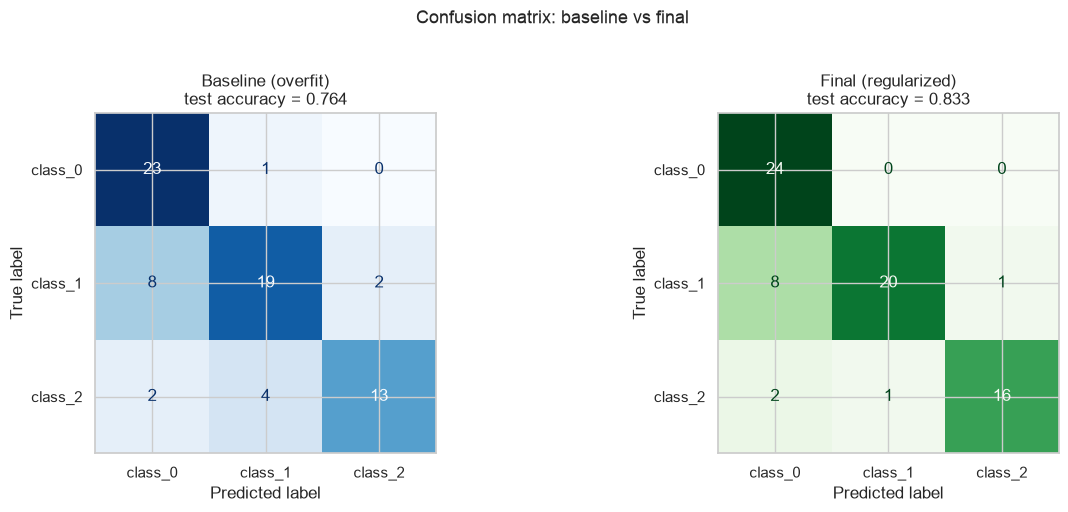

In [60]:
# твой код
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm_baseline, display_labels=data.target_names).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d"
)
axes[0].set_title(f"Baseline (overfit)\ntest accuracy = {test_acc_base:.3f}")

ConfusionMatrixDisplay(cm_final, display_labels=data.target_names).plot(
    ax=axes[1], cmap="Greens", colorbar=False, values_format="d"
)
axes[1].set_title(f"Final (regularized)\ntest accuracy = {test_acc_final:.3f}")

fig.suptitle("Confusion matrix: baseline vs final", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

В финальной матрице на диагонали больше чисел — больше правильных ответов. Off-diagonal — меньше. Регуляризация сохранила обобщающую способность даже на шумных тренировочных данных.

### 5.2.2 Общие метрики train/test для двух моделей

Соберём 4 главных числа (accuracy и macro-F1 на train и test) для baseline и final в одну таблицу. Так увидим, как закрылся gap.

In [61]:
# твой код
train_f1_base = f1_score(y_train, clf_baseline.predict(X_train), average="macro")
train_f1_final = f1_score(y_train, clf_final.predict(X_train), average="macro")
test_f1_base = f1_score(y_test, y_pred_baseline, average="macro")
test_f1_final = f1_score(y_test, y_pred_final, average="macro")

In [62]:
# твой код
metrics = pd.DataFrame({
    "metric": ["accuracy_train", "accuracy_test", "macro_f1_train", "macro_f1_test"],
    "baseline": [train_acc_base, test_acc_base, train_f1_base, test_f1_base],
    "final": [train_acc_final, test_acc_final, train_f1_final, test_f1_final],
})
metrics.round(3)

,metric,baseline,final
0,accuracy_train,1.000,0.934
1,accuracy_test,0.764,0.833
2,macro_f1_train,1.000,0.933
3,macro_f1_test,0.763,0.839


Эти же числа на bar chart:

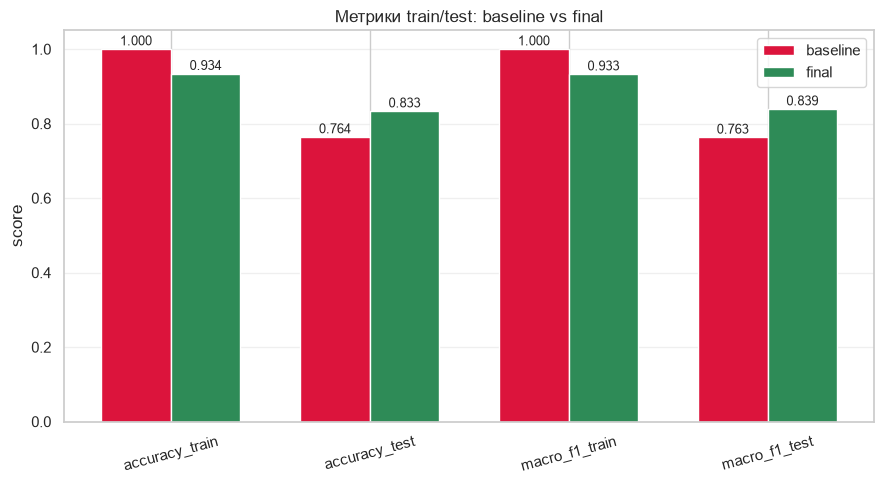

In [63]:
# твой код
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_b = ax.bar(x - width/2, metrics["baseline"], width, label="baseline", color="crimson")
bars_f = ax.bar(x + width/2, metrics["final"], width, label="final", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(metrics["metric"], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Метрики train/test: baseline vs final")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bars in (bars_b, bars_f):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

Train-метрики у baseline у самого верха (≈ 1.0), у final — пониже. Test-метрики у final **выше** baseline. Главное — сократился разрыв между train и test, модель стала **честнее**: она признаёт, что на 15% train разметка ошибочна, и не пытается их выучить.

### 5.2.3 Per-class F1

Какому именно классу регуляризация помогла? Считаем F1 отдельно для каждого из трёх классов.

In [64]:
# твой код
f1_per_class_base = f1_score(y_test, y_pred_baseline, average=None)
f1_per_class_final = f1_score(y_test, y_pred_final, average=None)

per_class = pd.DataFrame({
    "class": data.target_names,
    "baseline": np.round(f1_per_class_base, 3),
    "final": np.round(f1_per_class_final, 3),
})
per_class

,class,baseline,final
0,class_0,0.807,0.828
1,class_1,0.717,0.800
2,class_2,0.765,0.889


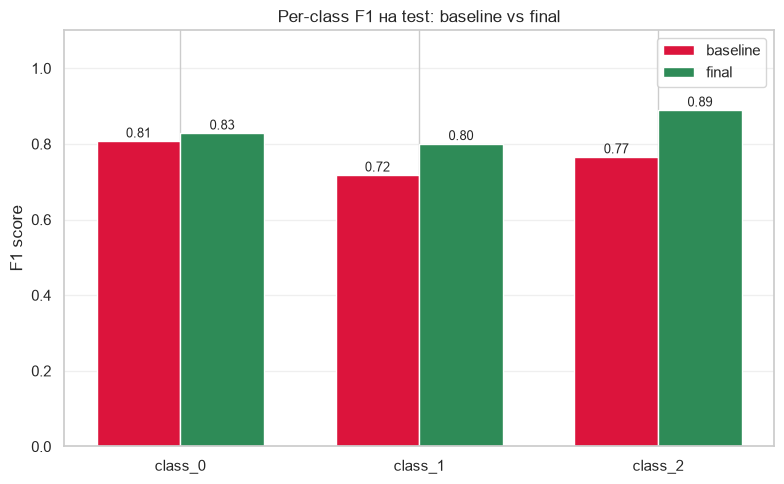

In [65]:
# твой код
x = np.arange(len(per_class))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, per_class["baseline"], width, label="baseline", color="crimson")
ax.bar(x + width/2, per_class["final"], width, label="final", color="seagreen")

for i, (b, f) in enumerate(zip(per_class["baseline"], per_class["final"])):
    ax.text(i - width/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + width/2, f + 0.01, f"{f:.2f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(per_class["class"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1 на test: baseline vs final")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

На multiclass общая accuracy может остаться той же, но один класс стал распознаваться сильно лучше за счёт другого. Per-class F1 это видит.

### 5.2.4 Сами деревья: side-by-side

Самый наглядный результат регуляризации — это сами деревья. Слева baseline без ограничений, справа final.

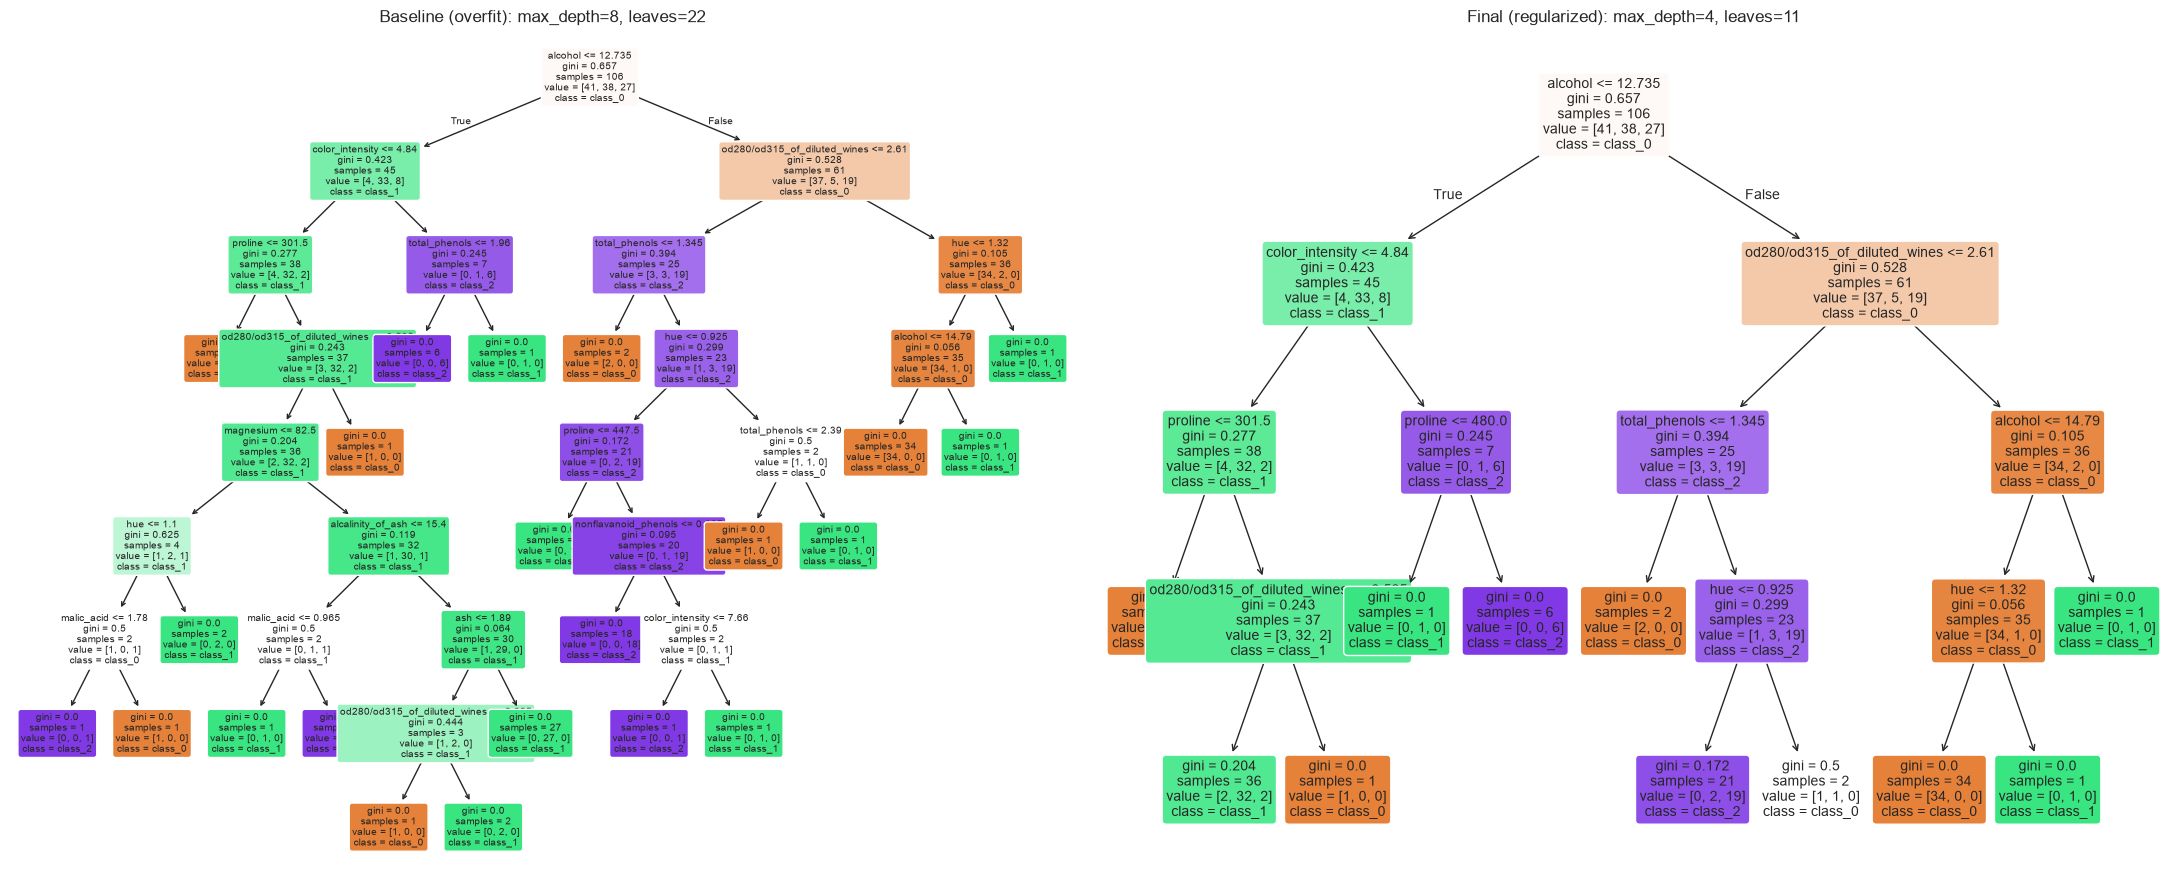

In [66]:
# твой код
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

plot_tree(
    clf_baseline,
    feature_names=list(X.columns),
    class_names=data.target_names,
    filled=True, rounded=True, fontsize=7,
    ax=axes[0],
)
axes[0].set_title(
    f"Baseline (overfit): max_depth={clf_baseline.tree_.max_depth}, "
    f"leaves={clf_baseline.get_n_leaves()}",
    fontsize=12,
)

plot_tree(
    clf_final,
    feature_names=list(X.columns),
    class_names=data.target_names,
    filled=True, rounded=True, fontsize=10,
    ax=axes[1],
)
axes[1].set_title(
    f"Final (regularized): max_depth={clf_final.tree_.max_depth}, "
    f"leaves={clf_final.get_n_leaves()}",
    fontsize=12,
)

plt.tight_layout()
plt.show()

Baseline-дерево слева разрослось до десятков узлов, многие из них существуют ради нескольких ошибочно размеченных точек. Финальное справа — компактное, 4-6 решающих узлов: его можно нарисовать на доске и объяснить бизнесу. Регуляризация — это буквально «обрезание лишних веток», и теперь это видно глазом.

### 5.2.5 Feature importance

Какие признаки модель реально использует в решающих сплитах.

In [67]:
# твой код
importances_final = pd.Series(clf_final.feature_importances_, index=X.columns)
importances_final.sort_values(ascending=False).head(10).round(4)

od280/od315_of_diluted_wines    0.3510
alcohol                         0.3506
color_intensity                 0.1176
hue                             0.0727
proline                         0.0566
total_phenols                   0.0515
malic_acid                      0.0000
ash                             0.0000
alcalinity_of_ash               0.0000
magnesium                       0.0000
dtype: float64

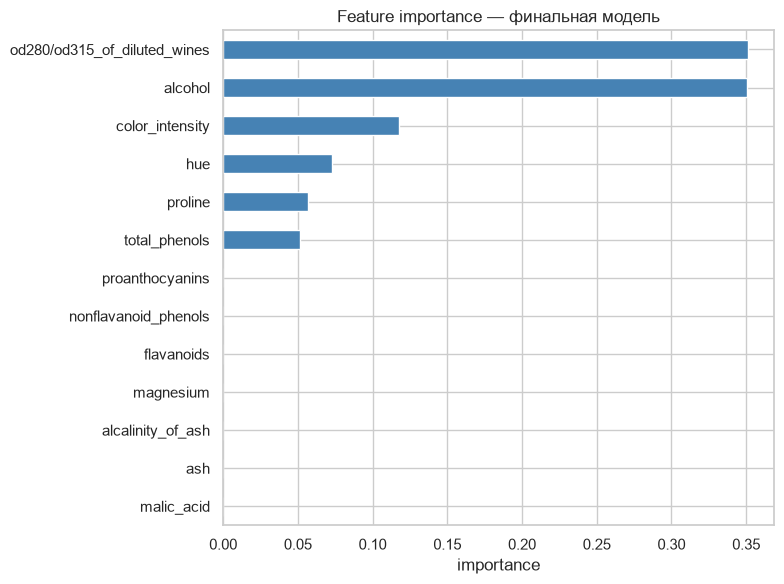

In [68]:
# твой код
top_n = importances_final.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
top_n.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature importance — финальная модель")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()

В верху рейтинга — `flavanoids`, `proline`, `color_intensity`. Те самые признаки, у которых на boxplot были раздельные коробки по классам. Сигнал ровно там, где он и должен был быть.

## Этап 6. Сохраняем модель в pickle

`joblib.dump` сериализует обученный объект `DecisionTreeClassifier` в бинарный `.pkl`-файл. На этапе сервиса (Шаг 3 проекта) FastAPI грузит этот файл одним вызовом `joblib.load` — внутри получаем тот же объект с теми же параметрами, готовый отвечать на `predict_proba`.

**Важно:** версия sklearn при сохранении и при загрузке должна совпадать. Иначе можно получить deprecation warning или прямую ошибку. На Шаге 5 проекта мы зафиксируем `scikit-learn==1.6.1` в `requirements.txt`.

In [69]:
# TODO: сохрани финальную модель в MODEL_PATH через joblib.dump(model, path).
# Потом распечатай размер файла в КБ.
joblib.dump(clf_final, MODEL_PATH)

size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Saved {MODEL_PATH} ({size_kb:.1f} KB)")


Saved wine_model.pkl (3.5 KB)


### 6.1 Sanity check: загружаем pickle и предсказываем

Это та же операция, которую FastAPI будет делать при старте на Шаге 3 проекта. Если здесь работает — будет работать и в сервисе.

In [70]:
# твой код
loaded = joblib.load(MODEL_PATH)
type(loaded).__name__

'DecisionTreeClassifier'

In [71]:
# твой код
sample = X_test.iloc[[0]]
sample

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
39,14.22,3.99,2.51,13.2,128.0,3.0,3.04,0.2,2.08,5.1,0.89,3.53,760.0


In [72]:
# твой код
true_class = data.target_names[y_test.iloc[0]]
predicted_class = data.target_names[loaded.predict(sample)[0]]
proba = loaded.predict_proba(sample)[0]

print(f"Истинный класс:        {true_class}")
print(f"Предсказанный класс:   {predicted_class}")
print(f"Вероятности:")
for cls, p in zip(data.target_names, proba):
    print(f"  {cls}: {p:.3f}")

Истинный класс:        class_0
Предсказанный класс:   class_0
Вероятности:
  class_0: 1.000
  class_1: 0.000
  class_2: 0.000


**Готово.** Файл `wine_model.pkl` лежит на диске и проходит sanity check — после загрузки он предсказывает правильный класс с понятными вероятностями. Этот же `joblib.load(...)` будет вызываться при старте FastAPI-сервиса.

## Что дальше

Возвращайся в `content.md` к **Шагу 2** — там начинается этап обёртки модели в сервис: Pydantic-схема для запроса, эндпоинт `/predict`, HTML-форма для браузера, тесты, CI/CD и проверка на публичном URL.